In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score

#### Importing the csv file containing the data

In [4]:
df_in = pd.read_csv("C:/Users/SOFT/Documents/YT Trending data/IN_youtube_trending_data.csv")

In [5]:
df_in.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description
0,Iot0eF6EoNA,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,2020-08-12T04:31:41Z,UCGqvJPRcv7aVFun-eTsatcA,FoxStarHindi,24,2020-08-12T00:00:00Z,sadak|sadak 2|mahesh bhatt|vishesh films|pooja...,9885899,224925,3979409,350210,https://i.ytimg.com/vi/Iot0eF6EoNA/default.jpg,False,False,Three Streams. Three Stories. One Journey. Sta...
1,x-KbnJ9fvJc,Kya Baat Aa : Karan Aujla (Official Video) Tan...,2020-08-11T09:00:11Z,UCm9SZAl03Rev9sFwloCdz1g,Rehaan Records,10,2020-08-12T00:00:00Z,[None],11308046,655450,33242,405146,https://i.ytimg.com/vi/x-KbnJ9fvJc/default.jpg,False,False,Singer/Lyrics: Karan Aujla Feat Tania Music/ D...
2,KX06ksuS6Xo,Diljit Dosanjh: CLASH (Official) Music Video |...,2020-08-11T07:30:02Z,UCZRdNleCgW-BGUJf-bbjzQg,Diljit Dosanjh,10,2020-08-12T00:00:00Z,clash diljit dosanjh|diljit dosanjh|diljit dos...,9140911,296533,6179,30058,https://i.ytimg.com/vi/KX06ksuS6Xo/default.jpg,False,False,CLASH official music video performed by DILJIT...
3,UsMRgnTcchY,Dil Ko Maine Di Kasam Video | Amaal M Ft.Ariji...,2020-08-10T05:30:49Z,UCq-Fj5jknLsUf-MWSy4_brA,T-Series,10,2020-08-12T00:00:00Z,hindi songs|2020 hindi songs|2020 new songs|t-...,23564512,743931,84162,136942,https://i.ytimg.com/vi/UsMRgnTcchY/default.jpg,False,False,Gulshan Kumar and T-Series presents Bhushan Ku...
4,WNSEXJJhKTU,"Baarish (Official Video) Payal Dev,Stebin Ben ...",2020-08-11T05:30:13Z,UCye6Oz0mg46S362LwARGVcA,VYRLOriginals,10,2020-08-12T00:00:00Z,VYRL Original|Mohsin Khan|Shivangi Joshi|Payal...,6783649,268817,8798,22984,https://i.ytimg.com/vi/WNSEXJJhKTU/default.jpg,False,False,VYRL Originals brings to you ‘Baarish’ - the b...


In [8]:
df_in.shape

(251277, 16)

> There are total 251277 rows as of 28/08/2025 in the dataset

In [11]:
df_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251277 entries, 0 to 251276
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   video_id           251277 non-null  object
 1   title              251277 non-null  object
 2   publishedAt        251277 non-null  object
 3   channelId          251277 non-null  object
 4   channelTitle       251276 non-null  object
 5   categoryId         251277 non-null  int64 
 6   trending_date      251277 non-null  object
 7   tags               251277 non-null  object
 8   view_count         251277 non-null  int64 
 9   likes              251277 non-null  int64 
 10  dislikes           251277 non-null  int64 
 11  comment_count      251277 non-null  int64 
 12  thumbnail_link     251277 non-null  object
 13  comments_disabled  251277 non-null  bool  
 14  ratings_disabled   251277 non-null  bool  
 15  description        231822 non-null  object
dtypes: bool(2), int64(5)

> There are null values in description and channelTitle field

#### Dropping columns that are not necessary for the analysis

In [15]:
df_in.drop(columns=['video_id','thumbnail_link','description'],inplace=True, errors='ignore')
df_in.head()

,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,comments_disabled,ratings_disabled
0,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,2020-08-12T04:31:41Z,UCGqvJPRcv7aVFun-eTsatcA,FoxStarHindi,24,2020-08-12T00:00:00Z,sadak|sadak 2|mahesh bhatt|vishesh films|pooja...,9885899,224925,3979409,350210,False,False
1,Kya Baat Aa : Karan Aujla (Official Video) Tan...,2020-08-11T09:00:11Z,UCm9SZAl03Rev9sFwloCdz1g,Rehaan Records,10,2020-08-12T00:00:00Z,[None],11308046,655450,33242,405146,False,False
2,Diljit Dosanjh: CLASH (Official) Music Video |...,2020-08-11T07:30:02Z,UCZRdNleCgW-BGUJf-bbjzQg,Diljit Dosanjh,10,2020-08-12T00:00:00Z,clash diljit dosanjh|diljit dosanjh|diljit dos...,9140911,296533,6179,30058,False,False
3,Dil Ko Maine Di Kasam Video | Amaal M Ft.Ariji...,2020-08-10T05:30:49Z,UCq-Fj5jknLsUf-MWSy4_brA,T-Series,10,2020-08-12T00:00:00Z,hindi songs|2020 hindi songs|2020 new songs|t-...,23564512,743931,84162,136942,False,False
4,"Baarish (Official Video) Payal Dev,Stebin Ben ...",2020-08-11T05:30:13Z,UCye6Oz0mg46S362LwARGVcA,VYRLOriginals,10,2020-08-12T00:00:00Z,VYRL Original|Mohsin Khan|Shivangi Joshi|Payal...,6783649,268817,8798,22984,False,False


#### Mapping the categoryIDs to corresponding Category Names

In [18]:
import json

with open("D:/c backup/Downloads/IN_category_id.json", 'r') as f:
    categories = json.load(f)["items"]

cat_dict = {}
for cat in categories:
    cat_dict[int(cat["id"])] = cat["snippet"]["title"]

In [20]:
df_in['category_name'] = df_in['categoryId'].map(cat_dict)

In [22]:
df_in.head()

,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,comments_disabled,ratings_disabled,category_name
0,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,2020-08-12T04:31:41Z,UCGqvJPRcv7aVFun-eTsatcA,FoxStarHindi,24,2020-08-12T00:00:00Z,sadak|sadak 2|mahesh bhatt|vishesh films|pooja...,9885899,224925,3979409,350210,False,False,Entertainment
1,Kya Baat Aa : Karan Aujla (Official Video) Tan...,2020-08-11T09:00:11Z,UCm9SZAl03Rev9sFwloCdz1g,Rehaan Records,10,2020-08-12T00:00:00Z,[None],11308046,655450,33242,405146,False,False,Music
2,Diljit Dosanjh: CLASH (Official) Music Video |...,2020-08-11T07:30:02Z,UCZRdNleCgW-BGUJf-bbjzQg,Diljit Dosanjh,10,2020-08-12T00:00:00Z,clash diljit dosanjh|diljit dosanjh|diljit dos...,9140911,296533,6179,30058,False,False,Music
3,Dil Ko Maine Di Kasam Video | Amaal M Ft.Ariji...,2020-08-10T05:30:49Z,UCq-Fj5jknLsUf-MWSy4_brA,T-Series,10,2020-08-12T00:00:00Z,hindi songs|2020 hindi songs|2020 new songs|t-...,23564512,743931,84162,136942,False,False,Music
4,"Baarish (Official Video) Payal Dev,Stebin Ben ...",2020-08-11T05:30:13Z,UCye6Oz0mg46S362LwARGVcA,VYRLOriginals,10,2020-08-12T00:00:00Z,VYRL Original|Mohsin Khan|Shivangi Joshi|Payal...,6783649,268817,8798,22984,False,False,Music


#### Let's deal with null values

In [25]:
df_in.isna().sum()

title                 0
publishedAt           0
channelId             0
channelTitle          1
categoryId            0
trending_date         0
tags                  0
view_count            0
likes                 0
dislikes              0
comment_count         0
comments_disabled     0
ratings_disabled      0
category_name        90
dtype: int64

In [27]:
null_title = df_in[df_in['channelTitle'].isnull()]
null_title

,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,comments_disabled,ratings_disabled,category_name
30289,Kala Official Teaser | Tovino Thomas | Rohith ...,2021-01-21T12:30:29Z,UCDQt0y-FCJLRdwhNLutPFZA,NaN,22,2021-01-23T00:00:00Z,Kala|Kala trailer|kala teaser|kala tovino thom...,1008638,72772,1451,3023,False,False,People & Blogs


In [29]:
#Droppint the record with null value
df_in.drop(null_title.index,inplace=True)

In [31]:
#Let's explore the null values in category_name
df_in[df_in['category_name'].isnull()]

,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,comments_disabled,ratings_disabled,category_name
1698,"हरतालिकेची कहाणी, शंकराने पार्वतीला सांगितलेली...",2020-08-20T10:22:58Z,UCoTF_xCCgkunYboLK0gmz8g,Webdunia Marathi,29,2020-08-21T00:00:00Z,hartalika kahani|hartalika katha|mahadev|parva...,300171,2097,263,125,False,False,NaN
1712,Hartalika Puja Vidhi हरतालिका पूजा विधी,2020-08-19T13:46:53Z,UCoTF_xCCgkunYboLK0gmz8g,Webdunia Marathi,29,2020-08-21T00:00:00Z,hartalika pujan vidhi|hartalika teej|hartalika...,231036,1216,169,53,False,False,NaN
1921,"हरतालिकेची कहाणी, शंकराने पार्वतीला सांगितलेली...",2020-08-20T10:22:58Z,UCoTF_xCCgkunYboLK0gmz8g,Webdunia Marathi,29,2020-08-22T00:00:00Z,hartalika kahani|hartalika katha|mahadev|parva...,400238,2521,341,266,False,False,NaN
1956,Hartalika Puja Vidhi हरतालिका पूजा विधी,2020-08-19T13:46:53Z,UCoTF_xCCgkunYboLK0gmz8g,Webdunia Marathi,29,2020-08-22T00:00:00Z,hartalika pujan vidhi|hartalika teej|hartalika...,248573,1269,178,60,False,False,NaN
2165,"हरतालिकेची कहाणी, शंकराने पार्वतीला सांगितलेली...",2020-08-20T10:22:58Z,UCoTF_xCCgkunYboLK0gmz8g,Webdunia Marathi,29,2020-08-23T00:00:00Z,hartalika kahani|hartalika katha|mahadev|parva...,426463,2601,368,272,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239245,Jenni PONNU PAAKUM Function!! *Jenni ku Kalyan...,2024-02-03T11:30:38Z,UCzrvQLPo0Ry_xWu9OzggzDg,Jenni’s Hacks,29,2024-02-05T00:00:00Z,jenni's hacks|hacks|crafts|timepass|useful|fun...,359928,10063,0,643,False,False,NaN
239473,Jenni PONNU PAAKUM Function!! *Jenni ku Kalyan...,2024-02-03T11:30:38Z,UCzrvQLPo0Ry_xWu9OzggzDg,Jenni’s Hacks,29,2024-02-06T00:00:00Z,jenni's hacks|hacks|crafts|timepass|useful|fun...,415476,11207,0,683,False,False,NaN
239711,Jenni PONNU PAAKUM Function!! *Jenni ku Kalyan...,2024-02-03T11:30:38Z,UCzrvQLPo0Ry_xWu9OzggzDg,Jenni’s Hacks,29,2024-02-07T00:00:00Z,jenni's hacks|hacks|crafts|timepass|useful|fun...,466511,12145,0,634,False,False,NaN
239901,पूज्य बापूजी के आज के मंगलमय दर्शन जोधपुर से (...,2024-02-06T10:27:00Z,UCMamNBjyzIR-824ZjntAXmg,Sant Shri Asharamji Ashram,29,2024-02-08T00:00:00Z,sant shri asharamji ashram|ashram|asharamji as...,20715,2056,0,239,False,False,NaN


> Looks like categoryID 29 does not have corresponding category name, we can label it as 'Miscellaneous'

In [34]:
df_in['category_name'] = df_in['category_name'].fillna('Miscellaneous')
df_in.isna().sum()

title                0
publishedAt          0
channelId            0
channelTitle         0
categoryId           0
trending_date        0
tags                 0
view_count           0
likes                0
dislikes             0
comment_count        0
comments_disabled    0
ratings_disabled     0
category_name        0
dtype: int64

> No more null values!

#### Tags column contains a huge string of tags, we can convert it to a list

In [38]:
df_in['tags']

0         sadak|sadak 2|mahesh bhatt|vishesh films|pooja...
1                                                    [None]
2         clash diljit dosanjh|diljit dosanjh|diljit dos...
3         hindi songs|2020 hindi songs|2020 new songs|t-...
4         VYRL Original|Mohsin Khan|Shivangi Joshi|Payal...
                                ...                        
251272    Tips Telugu|Hanuman chalisa|Hanuman telugu mov...
251273    army admit card|army admit card 2024|indian ar...
251274             comicverse|comic verse|comicverse marvel
251275    Daily Vlogs|Comedy Vlogs|Lifestyle Vlogs|Daily...
251276    Hero ISL|Indian Super League|Indian football|F...
Name: tags, Length: 251276, dtype: object

In [40]:
def clean_tags(tag):
    if tag == '[none]': return []
    return tag.lower().replace('"','').split('|')

df_in['tags'] = df_in['tags'].apply(clean_tags)
df_in.head()

,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,comments_disabled,ratings_disabled,category_name
0,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,2020-08-12T04:31:41Z,UCGqvJPRcv7aVFun-eTsatcA,FoxStarHindi,24,2020-08-12T00:00:00Z,"[sadak, sadak 2, mahesh bhatt, vishesh films, ...",9885899,224925,3979409,350210,False,False,Entertainment
1,Kya Baat Aa : Karan Aujla (Official Video) Tan...,2020-08-11T09:00:11Z,UCm9SZAl03Rev9sFwloCdz1g,Rehaan Records,10,2020-08-12T00:00:00Z,[[none]],11308046,655450,33242,405146,False,False,Music
2,Diljit Dosanjh: CLASH (Official) Music Video |...,2020-08-11T07:30:02Z,UCZRdNleCgW-BGUJf-bbjzQg,Diljit Dosanjh,10,2020-08-12T00:00:00Z,"[clash diljit dosanjh, diljit dosanjh, diljit ...",9140911,296533,6179,30058,False,False,Music
3,Dil Ko Maine Di Kasam Video | Amaal M Ft.Ariji...,2020-08-10T05:30:49Z,UCq-Fj5jknLsUf-MWSy4_brA,T-Series,10,2020-08-12T00:00:00Z,"[hindi songs, 2020 hindi songs, 2020 new songs...",23564512,743931,84162,136942,False,False,Music
4,"Baarish (Official Video) Payal Dev,Stebin Ben ...",2020-08-11T05:30:13Z,UCye6Oz0mg46S362LwARGVcA,VYRLOriginals,10,2020-08-12T00:00:00Z,"[vyrl original, mohsin khan, shivangi joshi, p...",6783649,268817,8798,22984,False,False,Music


#### Convert publishedAt and trending_date in same format

In [43]:
def clean_trending_date(date):
    y,m,d = date.split('T')[0].split('-')
    return datetime.date(int(y), int(m), int(d))

def clean_publish_time(time):
    y,m,d = time.split('T')[0].split('-')
    return datetime.date(int(y), int(m), int(d))

df_in['trending_date'] = df_in['trending_date'].apply(clean_trending_date)
df_in['publishedAt'] = df_in['publishedAt'].apply(clean_publish_time)

#### Adding some additional calculations

In [45]:
# Calculate engagement_rate, like_dislike_ratio, comment_view_ratio, dislikes_per_comment
df_in['engagement_rate'] = (df_in['likes'] + df_in['dislikes'] + df_in['comment_count']) / (df_in['view_count'] + 1e-6)
df_in['like_dislike_ratio'] = df_in['likes'] / (df_in['dislikes'] + 1e-6)
df_in['comment_view_ratio'] = df_in['comment_count'] / (df_in['view_count'] + 1e-6)
df_in['dislikes_per_comment'] = df_in['dislikes'] / (df_in['comment_count'] + 1e-6)

In [47]:
# Calculate days_since_publication, likes_per_day, comments_per_day, view_velocity
df_in['trending_date'] = pd.to_datetime(df_in['trending_date'], yearfirst=True, format='%Y-%m-%d')
df_in['days_since_publication'] = (df_in['trending_date'] - pd.to_datetime(df_in['publishedAt'])).dt.days
df_in['likes_per_day'] = df_in['likes'] / (df_in['days_since_publication'] + 1e-6)
df_in['comments_per_day'] = df_in['comment_count'] / (df_in['days_since_publication'] + 1e-6)
df_in['view_velocity'] = np.log(df_in['view_count'] + 1) / (df_in['days_since_publication'] + 1)

In [49]:
df_in.isna().sum()

title                     0
publishedAt               0
channelId                 0
channelTitle              0
categoryId                0
trending_date             0
tags                      0
view_count                0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
category_name             0
engagement_rate           0
like_dislike_ratio        0
comment_view_ratio        0
dislikes_per_comment      0
days_since_publication    0
likes_per_day             0
comments_per_day          0
view_velocity             0
dtype: int64

#### Dataset range

In [52]:
print(f'Trending videos ranges from {df_in['trending_date'].min()} to {df_in['trending_date'].max()}')
print(f'Published videos ranges from {df_in['publishedAt'].min()} to {df_in['publishedAt'].max()}')

Trending videos ranges from 2020-08-12 00:00:00 to 2024-04-15 00:00:00
Published videos ranges from 2020-07-23 to 2024-04-15


### Correlation Analysis

In [54]:
print("Columns in dataset:\n ", df_in.columns)

Columns in dataset:
  Index(['title', 'publishedAt', 'channelId', 'channelTitle', 'categoryId',
       'trending_date', 'tags', 'view_count', 'likes', 'dislikes',
       'comment_count', 'comments_disabled', 'ratings_disabled',
       'category_name', 'engagement_rate', 'like_dislike_ratio',
       'comment_view_ratio', 'dislikes_per_comment', 'days_since_publication',
       'likes_per_day', 'comments_per_day', 'view_velocity'],
      dtype='object')


In [55]:
numeric_df_in = df_in.select_dtypes(include=['int64', 'float64'])

In [57]:
corr_matrix = numeric_df_in.corr()
print("\nCorrelation Matrix:\n", corr_matrix)


Correlation Matrix:
                         categoryId  view_count     likes  dislikes  \
categoryId                1.000000   -0.125416 -0.090613 -0.009154   
view_count               -0.125416    1.000000  0.799752  0.110652   
likes                    -0.090613    0.799752  1.000000  0.069301   
dislikes                 -0.009154    0.110652  0.069301  1.000000   
comment_count            -0.095773    0.458001  0.619059  0.151245   
engagement_rate          -0.028680   -0.034253  0.211328  0.036254   
like_dislike_ratio       -0.039879    0.562228  0.677129 -0.009424   
comment_view_ratio       -0.104026   -0.003170  0.099424  0.028329   
dislikes_per_comment      0.019814    0.039676  0.011501  0.010602   
days_since_publication   -0.057412    0.338288  0.255575  0.037514   
likes_per_day            -0.034924    0.028357  0.111595  0.004940   
comments_per_day         -0.025935    0.034836  0.092546  0.011498   
view_velocity             0.011260   -0.120596 -0.069130 -0.012423  

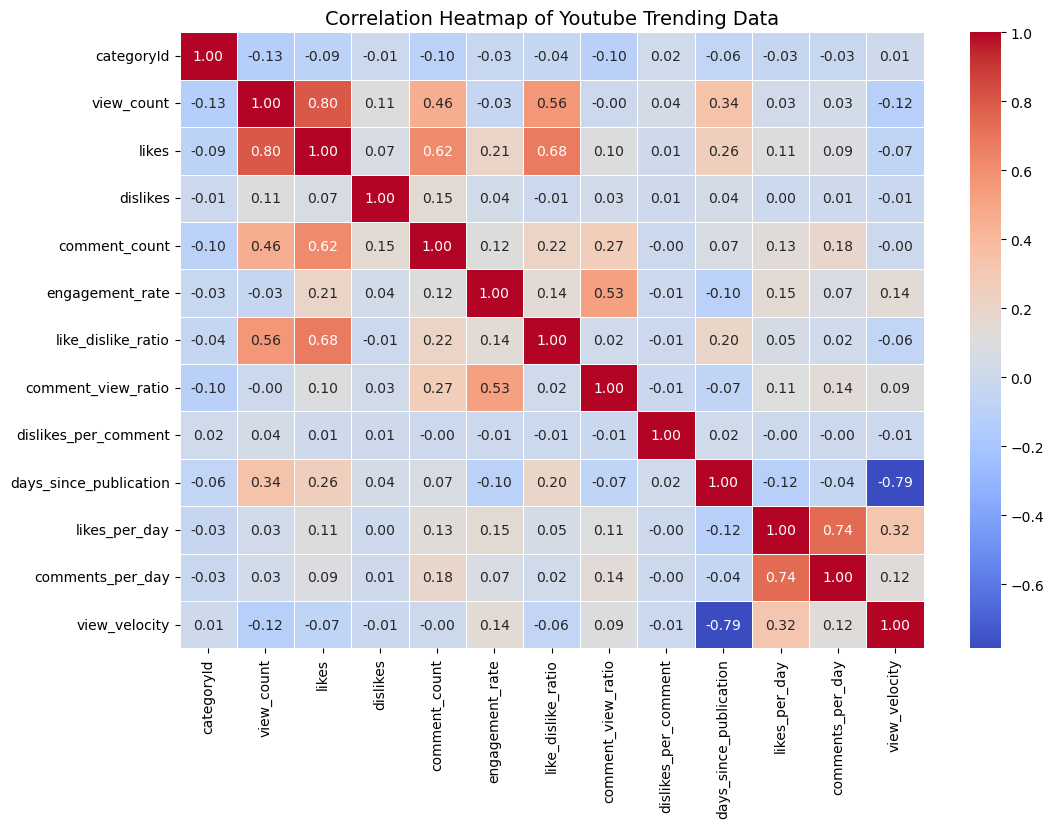

In [59]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Youtube Trending Data", fontsize=14)
plt.show()

In [60]:
if "view" in numeric_df_in.columns:
    corr_with_views = corr_matrix["view_count"].sort_values(ascending = False)
    print("\nCorrelation of attributes with Views:\n", corr_with_views)

In [63]:
if "view_count" in numeric_df_in.columns:
    corr_with_views = corr_matrix["view_count"].sort_values(ascending=False)
    print("\nCorrelation of attributes with Views:\n", corr_with_views)


Correlation of attributes with Views:
 view_count                1.000000
likes                     0.799752
like_dislike_ratio        0.562228
comment_count             0.458001
days_since_publication    0.338288
dislikes                  0.110652
dislikes_per_comment      0.039676
comments_per_day          0.034836
likes_per_day             0.028357
comment_view_ratio       -0.003170
engagement_rate          -0.034253
view_velocity            -0.120596
categoryId               -0.125416
Name: view_count, dtype: float64


In [65]:
if "likes" in numeric_df_in.columns:
    corr_with_likes = corr_matrix["likes"].sort_values(ascending=False)
    print("\nCorrelation of attributes with Likes:\n", corr_with_likes)


Correlation of attributes with Likes:
 likes                     1.000000
view_count                0.799752
like_dislike_ratio        0.677129
comment_count             0.619059
days_since_publication    0.255575
engagement_rate           0.211328
likes_per_day             0.111595
comment_view_ratio        0.099424
comments_per_day          0.092546
dislikes                  0.069301
dislikes_per_comment      0.011501
view_velocity            -0.069130
categoryId               -0.090613
Name: likes, dtype: float64


In [67]:
corr_likes_comments = df_in['likes'].corr(df_in['comment_count'])
print("\nCorrelation of Likes with Comments:\n", corr_likes_comments)


Correlation of Likes with Comments:
 0.6190587679419999


In [69]:
corr_likes_engagement = df_in['likes'].corr(df_in['engagement_rate'])
print("\nCorrelation of Likes with Engagement Rate:\n", corr_likes_engagement)


Correlation of Likes with Engagement Rate:
 0.2113281298023637


In [71]:
corr_dislikes_engagement = df_in['dislikes'].corr(df_in['engagement_rate'])
print("\nCorrelation of Dislikes with Engagement Rate:\n", corr_dislikes_engagement)


Correlation of Dislikes with Engagement Rate:
 0.03625420775622119


In [73]:
corr_likes_comment = df_in['likes'].corr(df_in['comment_count'])
print("\nCorrelation of Likes with Comment Count:\n", corr_likes_comment)


Correlation of Likes with Comment Count:
 0.6190587679419999


In [75]:
corr_view_dislike = df_in['view_count'].corr(df_in['dislikes'])
print("\nCorrelation of View Count with DisLikes :\n", corr_view_dislike)


Correlation of View Count with DisLikes :
 0.11065165781706551


In [77]:
corr_dislikes_comment = df_in['dislikes'].corr(df_in['comment_count'])
print("\nCorrelation of Dislikes with Comment Count:\n", corr_dislikes_comment)


Correlation of Dislikes with Comment Count:
 0.1512454143650875


In [79]:
corr_engagement_pub = df_in['engagement_rate'].corr(df_in['days_since_publication'])
print("\nCorrelation of Engagement Rate with Days since Publication:\n", corr_engagement_pub)


Correlation of Engagement Rate with Days since Publication:
 -0.09874110088384078


### Natural Language Processing for title

In [89]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [93]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_titles(title):
    tokens = title.lower().split()
    cleaned = []
    sw = set(stopwords.words('english'))
    for token in tokens:
        if token.startswith('$') or token.isnumeric() or not token.isalnum() or token in sw:  # Remove money amount, non-alphanumeric tokens, or stopwords
            continue
        else:
            cleaned.append(token)
    return ' '.join(cleaned)

df_in['title_cl'] = df_in['title'].apply(clean_titles)

df_in.head(2)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SOFT\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,...,category_name,engagement_rate,like_dislike_ratio,comment_view_ratio,dislikes_per_comment,days_since_publication,likes_per_day,comments_per_day,view_velocity,title_cl
0,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,2020-08-12,UCGqvJPRcv7aVFun-eTsatcA,FoxStarHindi,24,2020-08-12,"[sadak, sadak 2, mahesh bhatt, vishesh films, ...",9885899,224925,3979409,...,Entertainment,0.460711,0.056522,0.035425,11.362922,0,2.249250e+11,3.502100e+11,16.106620,sadak official trailer sanjay pooja alia adity...
1,Kya Baat Aa : Karan Aujla (Official Video) Tan...,2020-08-11,UCm9SZAl03Rev9sFwloCdz1g,Rehaan Records,10,2020-08-12,[[none]],11308046,655450,33242,...,Music,0.096731,19.717526,0.035828,0.082049,1,6.554493e+05,4.051456e+05,8.120513,kya baat aa karan aujla tania sukh sanghera de...


- Above code cleans the title of the videos by converting it to lower case and removing money values,non-alphanumeric tokern and stopwords

In [100]:
from collections import Counter

cnt = Counter()

# Finding the occurence of words in video titles
for title in df_in['title_cl']:
    for token in title.split():
        cnt[token] += 1

# Finding the 50 most used words in video titles
dist = cnt.most_common(50)
top_words = []
freqs = []
for word, freq in dist:
    top_words.append(word)
    freqs.append(freq)

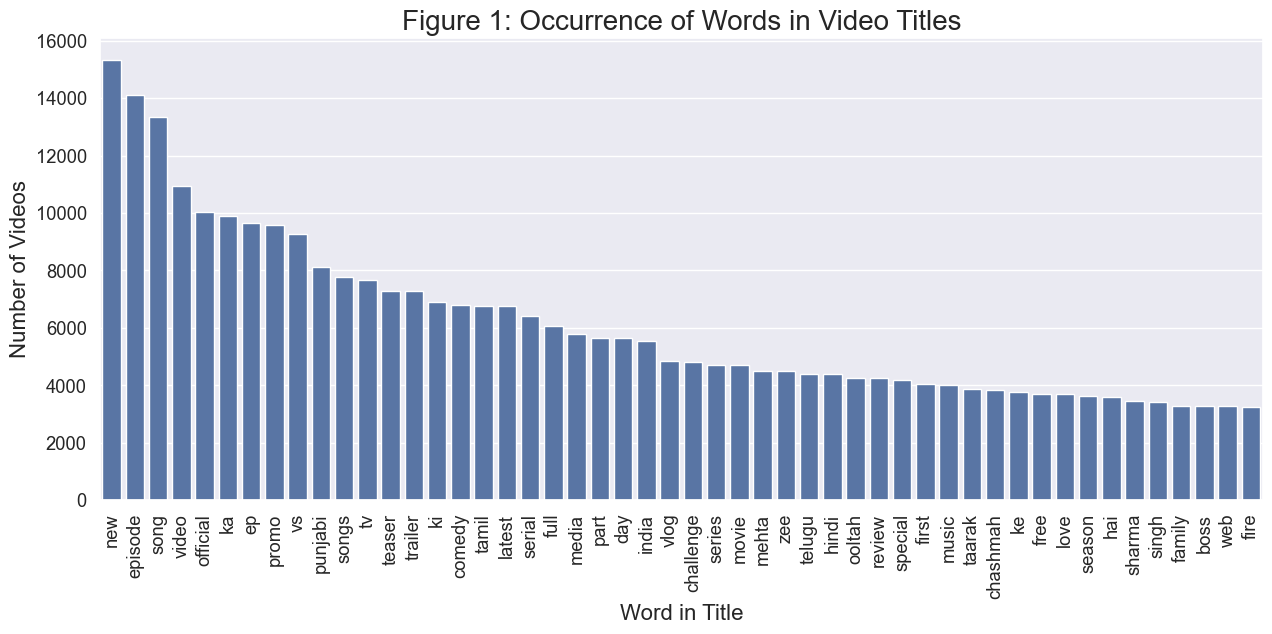

In [102]:
# Graphing number of times the world occure in title
fig= plt.figure(figsize=(15,6))
sns.set(font_scale=1.2)

sns.barplot(x=top_words,y=freqs)

plt.xticks(rotation=90)
plt.xlabel('Word in Title', fontsize=16)
plt.ylabel('Number of Videos', fontsize=16)
plt.title('Figure 1: Occurrence of Words in Video Titles', fontsize=20)
plt.show()

- We can see that the top ten words are new,episode,song,video,official,ka,ep,promo,vs,trailer
- Titles with words "new season","new trailer","new season","new song" trends a lot

### Applying suitable Machine learning Model

In [58]:
df_in.isna().sum()

title                     0
publishedAt               0
channelId                 0
channelTitle              0
categoryId                0
trending_date             0
tags                      0
view_count                0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
category_name             0
engagement_rate           0
like_dislike_ratio        0
comment_view_ratio        0
dislikes_per_comment      0
days_since_publication    0
likes_per_day             0
comments_per_day          0
view_velocity             0
dtype: int64

In [54]:
df = df_in
df.drop(["comments_disabled","ratings_disabled","category_name"],axis=1,inplace=True)

### Separating the dataset
- First dataset will be from (2020-2022) for training purpose 
- Second dataset will be from 2023 to see the accuracy
- Third dataset will be used to predict the current top trending videos in dataset

In [57]:
df_in['publishedAt'] = pd.to_datetime(df_in['publishedAt'])

start_date_2020 = pd.to_datetime('2020-01-01')
end_date_2022 = pd.to_datetime('2022-12-31')
start_date_2023 = pd.to_datetime('2023-01-01')
start_date_2024 = pd.to_datetime('2024-01-01')

train_data = df_in[(df_in['publishedAt'] >= start_date_2020) & (df_in['publishedAt'] <= end_date_2022)]
test_data = df_in[(df_in['publishedAt'] >= start_date_2023) & (df_in['publishedAt'] <= start_date_2023 + pd.DateOffset(years=1, days=-1))]
prediction_data = df_in[df_in['publishedAt'] >= start_date_2024]

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)
print("Prediction data shape:", prediction_data.shape)

Training data shape: (168085, 19)
Testing data shape: (65270, 19)
Prediction data shape: (17921, 19)


## Applying Random Forest Regressor 

### Training the model

In [61]:
#features
X = ['view_count', 'likes', 'dislikes', 'comment_count', 'engagement_rate', 'like_dislike_ratio','comment_view_ratio', 'dislikes_per_comment', 'days_since_publication', 'likes_per_day', 'comments_per_day']

#split the data 
X_train = train_data[X]
y_train = train_data['view_velocity']

X_test = test_data[X]

In [63]:
model = RandomForestRegressor(n_estimators=132, random_state=0)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=132, random_state=0)

In [65]:
#make prediction on the test data
y_pred = model.predict(X_test)

#extract view_velocity from test_data
y_test = test_data['view_velocity']

#mse
mse = mean_squared_error(y_test, y_pred)

In [67]:
# Check for infinity values in X_train
inf_mask = np.isinf(X_train)
inf_columns = X_train.columns[inf_mask.any()]

# Check for very large values in X_train
large_mask = np.abs(X_train) > 1e10
large_columns = X_train.columns[large_mask.any()]

print("Features with infinity values:", inf_columns)
print("Features with very large values:", large_columns)

Features with infinity values: Index([], dtype='object')
Features with very large values: Index(['like_dislike_ratio', 'dislikes_per_comment', 'likes_per_day',
       'comments_per_day'],
      dtype='object')


In [69]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Calculate Explained Variance Score
evs = explained_variance_score(y_test, y_pred)
print("Explained Variance Score:", evs)


Mean Squared Error: 5.3454778413283535e-06
Root Mean Squared Error: 0.0023120289447427674
Mean Absolute Error: 0.0001700917779980922
Explained Variance Score: 0.9999989511346908


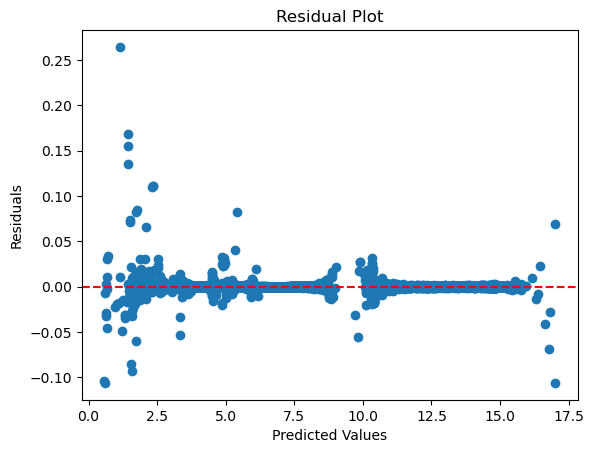

In [71]:
# Plot Residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

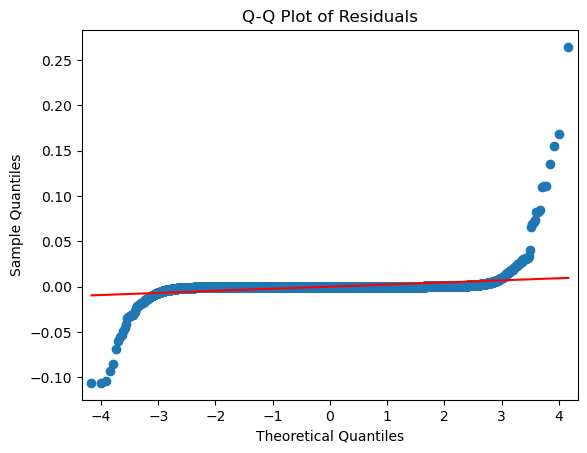

In [73]:
# Quantile-Quantile (Q-Q) Plot of Residuals
import statsmodels.api as sm
qqplot = sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

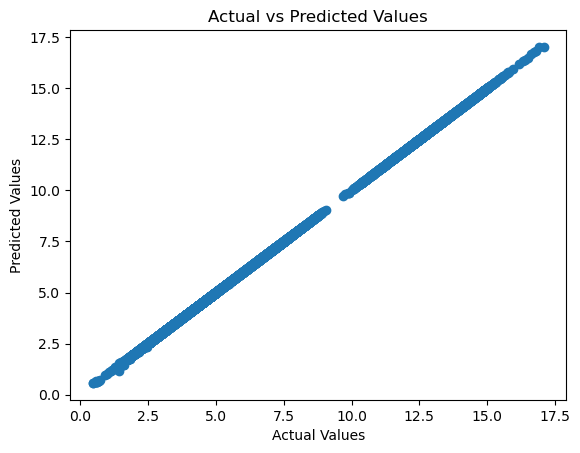

In [75]:
# Visualize Predicted vs Actual Values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [81]:
# Select features for testing
X_test = test_data[X]

# Make predictions on the test data
y_pred = model.predict(X_test)

# Create a DataFrame to store the predicted results
prediction_results = pd.DataFrame({'Title': test_data['title'], 
                                   'Channel': test_data['channelTitle'],
                                   'Trending Date': test_data['trending_date'],
                                   'Actual View Velocity': test_data['view_velocity'],
                                   'Predicted View Velocity': y_pred})


# Display the prediction results
print(prediction_results)

                                                    Title  \
167636  The Kapil Sharma Show : Khan Sir, Gaur Gopal D...   
167658  Thunivu Official Trailer | Ajith Kumar | H Vin...   
167669  Buying Season 1 Booyah Pass And 2000+++ Levels...   
167783             Bakra Nahi Majnu Halaal - Amit Bhadana   
167784                 BADGE99 OFFICIAL FACE REVEAL VIDEO   
...                                                   ...   
233924  Ishq Murshid - Episode 13 [𝐂𝐂] - 31 Dec 23 - S...   
233937  Jan - Dec 2023 Current Affairs Revision | Comp...   
233944  MAKE JOKE OF ||MJO|| - SAD NEW YEAR || by Saur...   
234074                AJJUBHAI FACE REVEAL | TOTAL GAMING   
234083  Kurchi Madathapetti Lyric Video |Guntur Kaaram...   

                     Channel Trending Date  Actual View Velocity  \
167636     Bollywood Hungama    2023-01-01             13.859122   
167658  OUR STUPID REACTIONS    2023-01-01             11.002050   
167669          LOKESH GAMER    2023-01-01             12.24215

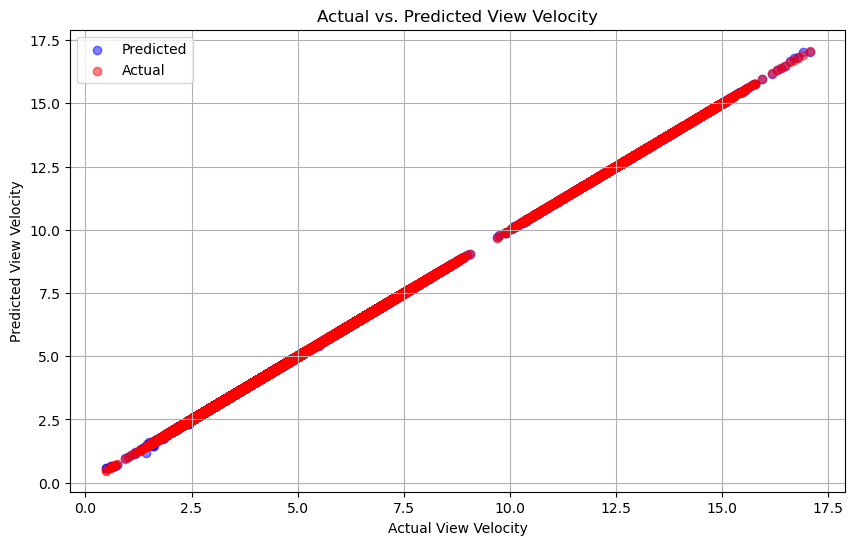

In [83]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(prediction_results['Actual View Velocity'], prediction_results['Predicted View Velocity'], color='blue', label='Predicted', alpha=0.5)
plt.scatter(prediction_results['Actual View Velocity'], prediction_results['Actual View Velocity'], color='red', label='Actual', alpha=0.5)
plt.title('Actual vs. Predicted View Velocity')
plt.xlabel('Actual View Velocity')
plt.ylabel('Predicted View Velocity')
plt.legend()
plt.grid(True)
plt.show()

In [85]:
# Select features for prediction
X_pred = prediction_data[X]

# Make predictions on the prediction data
predictions = model.predict(X_pred)

# Combine the predictions with video information
prediction_results = pd.DataFrame({'Title': prediction_data['title'], 'Channel': prediction_data['channelTitle'],
                                   'Published Date': prediction_data['publishedAt'], 'Trending Date': pd.to_datetime('2024-01-01'),
                                   'Predicted View Velocity': predictions})

# Sort the prediction results by predicted view velocity in descending order
prediction_results = prediction_results.sort_values(by='Predicted View Velocity', ascending=False)

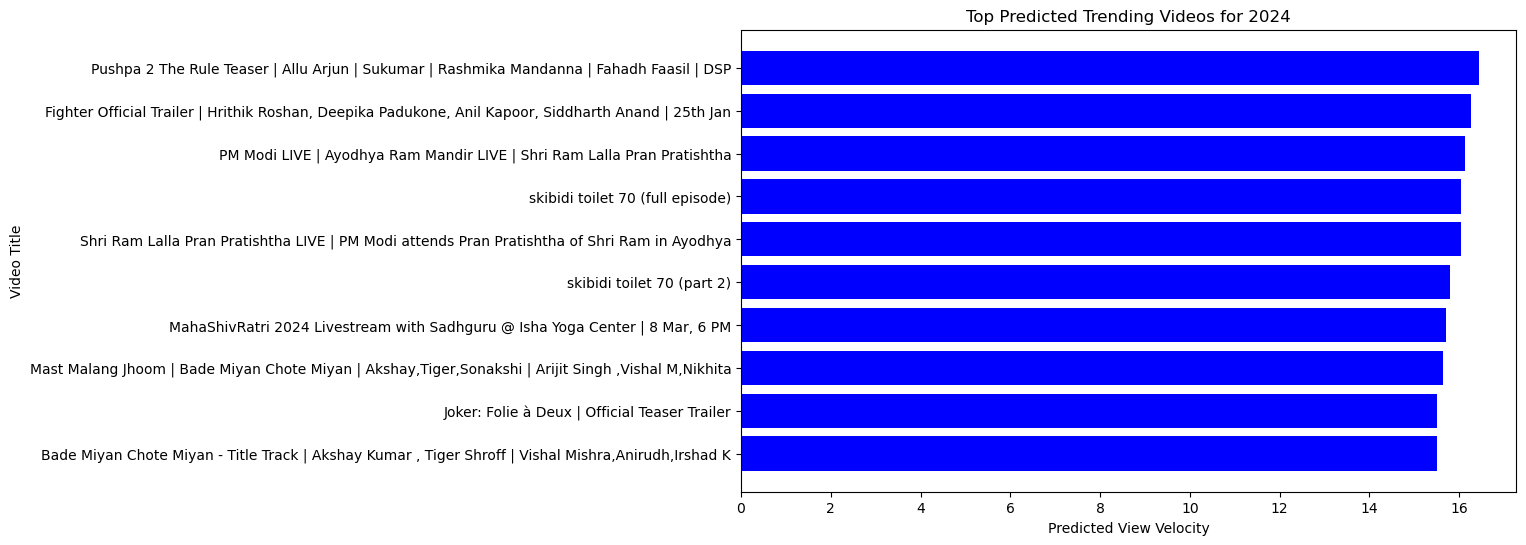

In [89]:
# Visualize the top predicted videos
plt.figure(figsize=(10, 6))
plt.barh(prediction_results['Title'][:10], prediction_results['Predicted View Velocity'][:10], color='blue')
plt.xlabel('Predicted View Velocity')
plt.ylabel('Video Title')
plt.title('Top Predicted Trending Videos for 2024')
plt.gca().invert_yaxis()
plt.show()